# HEFEX III 2025

In [31]:
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import pandas as pd

# Load HEFEXIII 20 Hz flux datasets
hefex_root = Path("data/HEFEXIII")
smartflux_path = hefex_root / "fluxes_20Hz_smartflux.nc"
standard_path = hefex_root / "fluxes_20Hz.nc"

smartflux_ds = xr.open_dataset(smartflux_path)
standard_ds = xr.open_dataset(standard_path)

smartflux_ds, standard_ds

print(standard_ds.data_vars)

Data variables:
    meanU    (time, heights) float64 39kB ...
    meanT    (time, heights) float32 20kB ...
    uu       (time, heights) float64 39kB ...
    vv       (time, heights) float64 39kB ...
    ww       (time, heights) float64 39kB ...
    uv       (time, heights) float64 39kB ...
    uw       (time, heights) float64 39kB ...
    vw       (time, heights) float64 39kB ...
    TT       (time, heights) float32 20kB ...
    uT       (time, heights) float64 39kB ...
    vT       (time, heights) float64 39kB ...
    wT       (time, heights) float64 39kB ...
    sdir     (time, heights) float64 39kB ...
    tke      (time, heights) float64 39kB ...
    uuu      (time, heights) float64 39kB ...
    vvv      (time, heights) float64 39kB ...
    www      (time, heights) float64 39kB ...
    TTT      (time, heights) float32 20kB ...
    uuv      (time, heights) float64 39kB ...
    uuw      (time, heights) float64 39kB ...
    uvw      (time, heights) float64 39kB ...
    uvv      (time

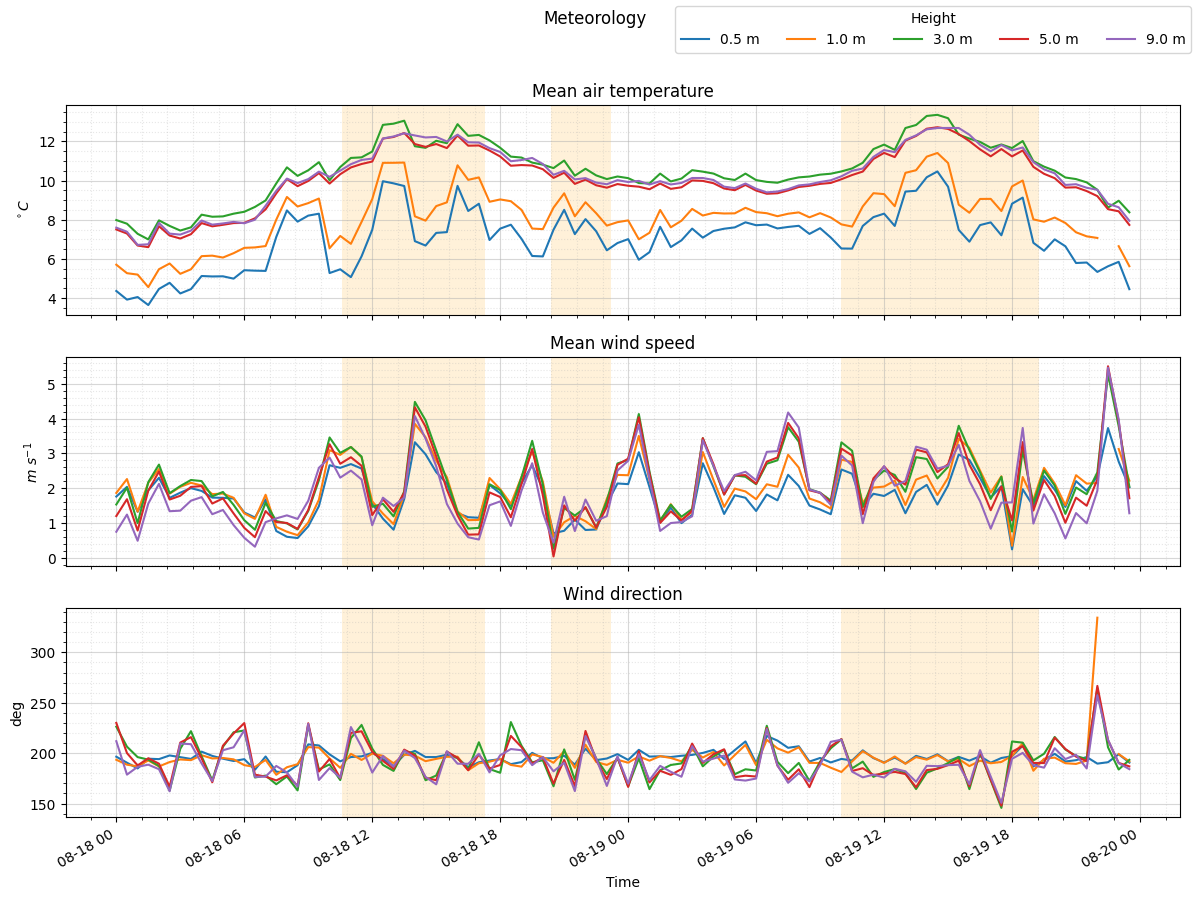

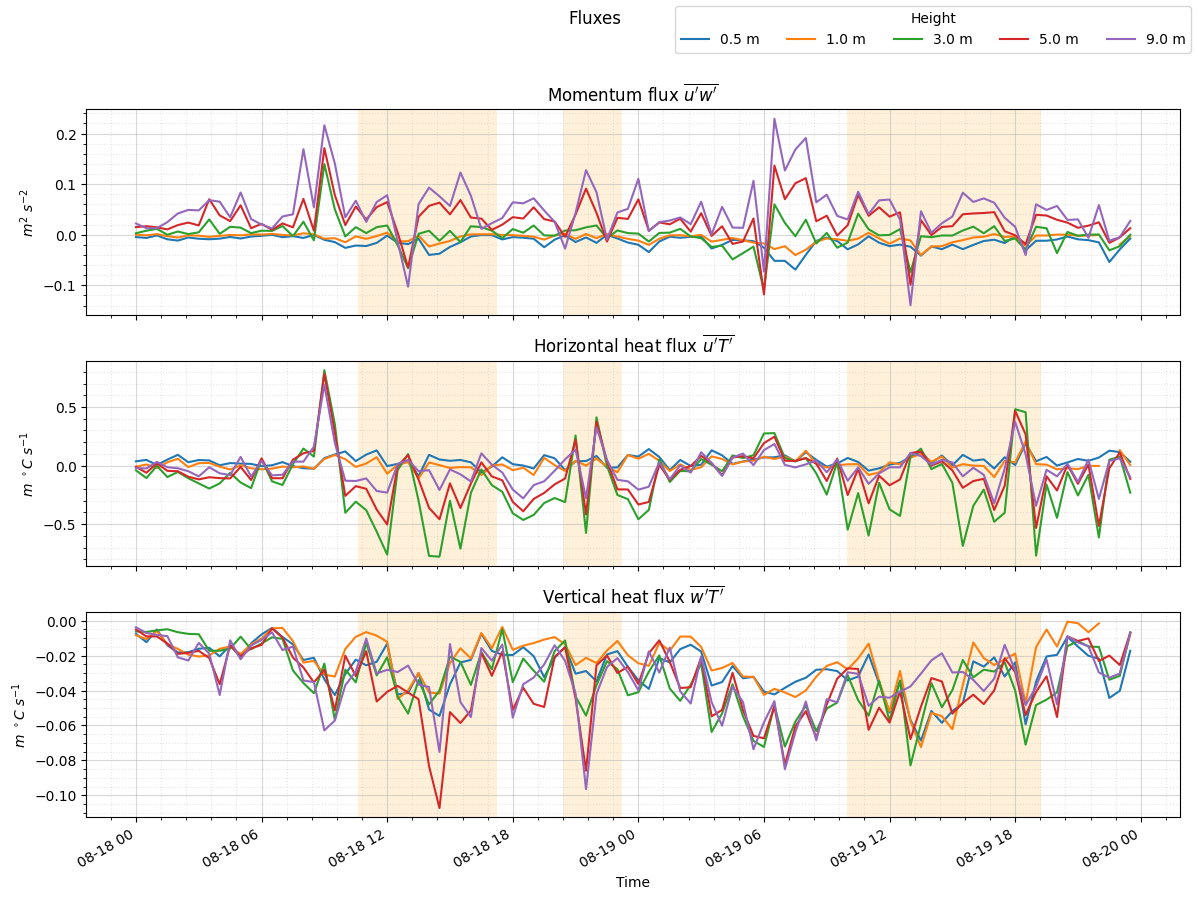

In [29]:
# Filter to Aug 18-19, 2025 and overlay all heights per variable (treat sensors the same)
subset_std = standard_ds.sel(time=slice("2025-08-18", "2025-08-19"))
subset_smart = smartflux_ds.sel(time=slice("2025-08-18", "2025-08-19"))
heights_std = subset_std.heights.values
heights_smart = subset_smart.heights.values if "heights" in subset_smart.coords else []
all_heights = sorted(set(heights_std.tolist() + heights_smart.tolist()))
highlight = [
    (pd.to_datetime('2025-08-18 10:35'), pd.to_datetime('2025-08-18 17:16')),
    (pd.to_datetime('2025-08-18 20:23'), pd.to_datetime('2025-08-18 23:12')),
    (pd.to_datetime('2025-08-19 09:58'), pd.to_datetime('2025-08-19 19:15')),
]

vars_panel1 = [
    ("meanT", "Mean air temperature", r"$^\circ C$"),
    ("meanU", "Mean wind speed", r"$m\ s^{-1}$"),
    ("sdir", "Wind direction", r"deg"),
]
vars_panel2 = [
    ("uw", r"Momentum flux $\overline{u'w'}$", r"$m^2\ s^{-2}$"),
    ("uT", r"Horizontal heat flux $\overline{u'T'}$", r"$m\ ^\circ C\ s^{-1}$"),
    ("wT", r"Vertical heat flux $\overline{w'T'}$", r"$m\ ^\circ C\ s^{-1}$"),
]

# Helper to plot a list of variables on stacked subplots

def plot_panel(var_list, title_prefix):
    fig, axes = plt.subplots(len(var_list), 1, figsize=(12, 9), sharex=True)
    if len(var_list) == 1:
        axes = [axes]
    for ax, (name, title, unit) in zip(axes, var_list):
        has_var = False
        for hval in all_heights:
            series = None
            if name in subset_std and hval in subset_std.heights.values:
                series = subset_std[name].sel(heights=hval).to_pandas()
            elif name in subset_smart and hval in subset_smart.heights.values:
                series = subset_smart[name].sel(heights=hval).to_pandas()
            if series is None:
                continue
            ax.plot(series.index, series.values, label=f"{float(hval)} m")
            has_var = True
        if not has_var:
            ax.set_visible(False)
            continue
        for start, end in highlight:
            ax.axvspan(start, end, color='orange', alpha=0.15, lw=0)
        ax.set_title(title)
        ax.set_ylabel(unit)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.grid(True, which="major", alpha=0.5)
        ax.grid(True, which="minor", alpha=0.3, linestyle=":")
    axes[-1].set_xlabel("Time")
    fig.autofmt_xdate()
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Height", loc="upper right", ncol=len(all_heights))
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.suptitle(title_prefix, y=0.995)
    return fig

fig1 = plot_panel(vars_panel1, "Meteorology")
fig2 = plot_panel(vars_panel2, "Fluxes")
